In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
from AIce.functions import testloader,redim,getRMSE
from  AIce.models import NNforNorms,simplrNNforNorms
from AIce.plotting import ResidualOnTheMap,PredAgainstTarget

In [ ]:
def get_output_norm(filepath, weightpath, inlist, targt='buoynorm', model='NNforNorms', 
                    means={},stds={},maxes={},trainingset_loaded=True,training_file='',
                    device='cuda'):
    """Return the output of a model based on the model name (weight)\n
        NEED TO DO THE EXP1M or inver Z-score aka NON DIMENSIONAL OUTPUT"""
        

    modeldata,_,_,_,_,_,_=testloader(filepath,inputlist=inlist ,target=targt,
                                trainingset_loaded=trainingset_loaded, training_file=training_file,
                                means=means,stds=stds,maxes=maxes)# Get the means,stds,maxes using the longest list possible
    if model=='NNforNorms':
        mlp256= NNforNorms(len(inlist)).to(device) # Creates a model for the specific n_inputs
    elif model=='simplrNNforNorms':
        mlp256=simplrNNforNorms(len(inlist)).to(device)
    else:
        print('Not good name for model')
        exit
    mlp256.load_state_dict(torch.load(weightpath, weights_only=True))# loads the weights onto the model
    mlp256.eval()  # if you're doing inference, not continuing training

    out=mlp256(torch.tensor(modeldata.drop(['buoynorm'], axis=1).values, dtype= torch.float32).to(device)).to('cpu')# runs the data into the model 
    return out

In [30]:
device='cuda'
allinput=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']

testdata,_,_,means,stds,maxes,labels=testloader('../data/DRIFT_DATA_TEST.csv',inputlist=allinput ,target='buoynorm',
                                trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv')# Get the means,stds,maxes using the longest list possible


testdata=redim(testdata,
               means=means,
               stds=stds,
               maxes=maxes)
#testdata['usual+windnorm']=np.expm1(out.detach().numpy()) # save the model prediction in the datapd with name associated to n_inputs


Bath size is the full test set
Target is buoynorm normalized by log1p
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score


In [31]:
filepath='../data/DRIFT_DATA_TEST.csv'
weightpath='../2.October/weights/simplr_Norms_5inputs_20E_0.001lr_09-16h_22m_09s.pt'
inlist=['u_ERA5', 'v_ERA5', 'h_piomas', 'bath', 'windnorm']
testdata['simplr']=np.expm1(get_output_norm(filepath, weightpath, inlist, targt='buoynorm', model='simplrNNforNorms', 
                    means=means,stds=stds,maxes=maxes,trainingset_loaded=True,training_file='',
                    device='cuda').detach().numpy())

#############################################################################

filepath='../data/DRIFT_DATA_TEST.csv'
weightpath='../2.October/weights/Norms_5inputs_20E_0.001lr_09-15h_18m_58s.pt'
inlist=['u_ERA5', 'v_ERA5', 'h_piomas', 'bath', 'windnorm']
testdata['256']=np.expm1(get_output_norm(filepath, weightpath, inlist, targt='buoynorm', model='NNforNorms', 
                    means=means,stds=stds,maxes=maxes,trainingset_loaded=True,training_file='',
                    device='cuda').detach().numpy())


Bath size is the full test set
Target is buoynorm normalized by log1p
Bathymetry (bath) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
Bath size is the full test set
Target is buoynorm normalized by log1p
Bathymetry (bath) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score


Rmse:  5.657418000534144


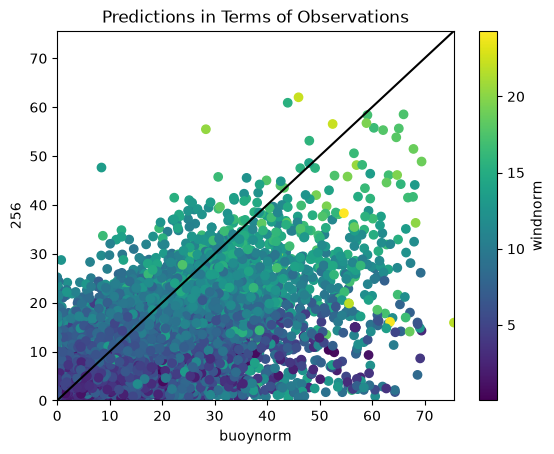

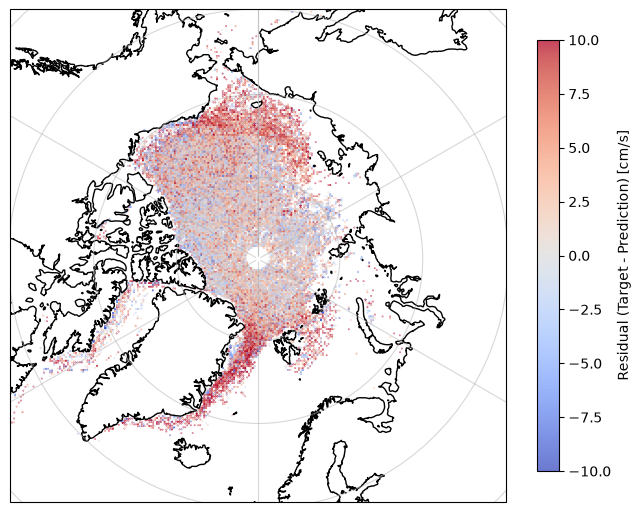

Rmse:  5.731872045772893


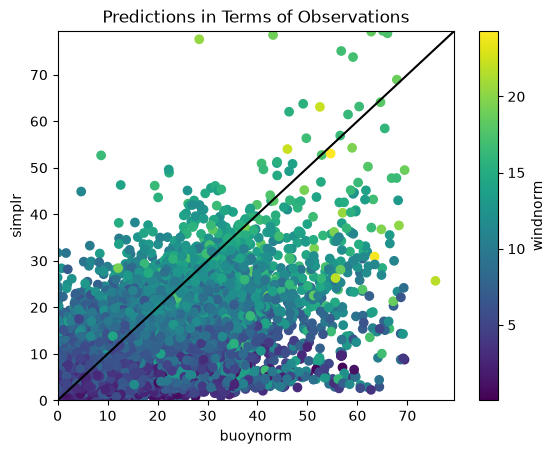

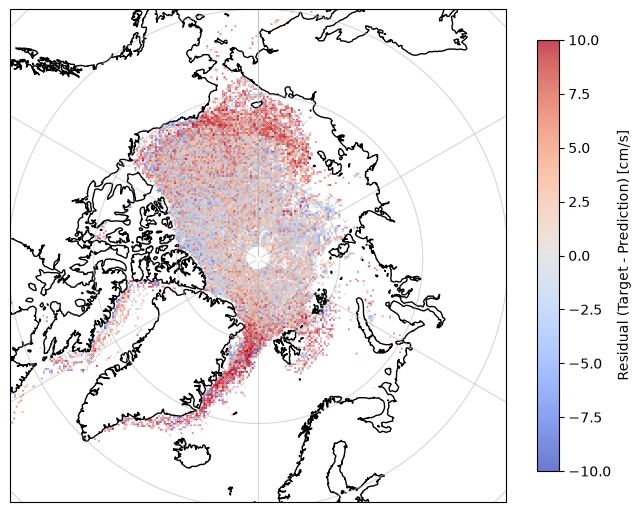

In [34]:
rmse=getRMSE(testdata['buoynorm'].values, testdata['256'].values)
print('Rmse: ', rmse)
PredAgainstTarget(testdata['buoynorm'], testdata['256'], testdata['windnorm'])
ResidualOnTheMap(testdata,'256', 'buoynorm')

rmse=getRMSE(testdata['buoynorm'].values, testdata['simplr'].values)
print('Rmse: ', rmse)
PredAgainstTarget(testdata['buoynorm'], testdata['simplr'], testdata['windnorm'])
ResidualOnTheMap(testdata,'simplr', 'buoynorm')

In [26]:
print(testdata['simplr'])

0        1.889225
1        1.889225
2        1.889225
3        1.889225
4        1.889225
           ...   
84784    1.889225
84785    1.889225
84786    1.889225
84787    1.889225
84788    1.889225
Name: simplr, Length: 84789, dtype: float32


Index(['buoynorm', 'x_EASE', 'y_EASE', 'u_ERA5', 'v_ERA5', 'sic_CDR',
       'h_piomas', 'sin', 'cos', 'bath', 'windnorm', 'bath+wind', 'bathnowind',
       'usual', 'usual+windnorm'],
      dtype='object')


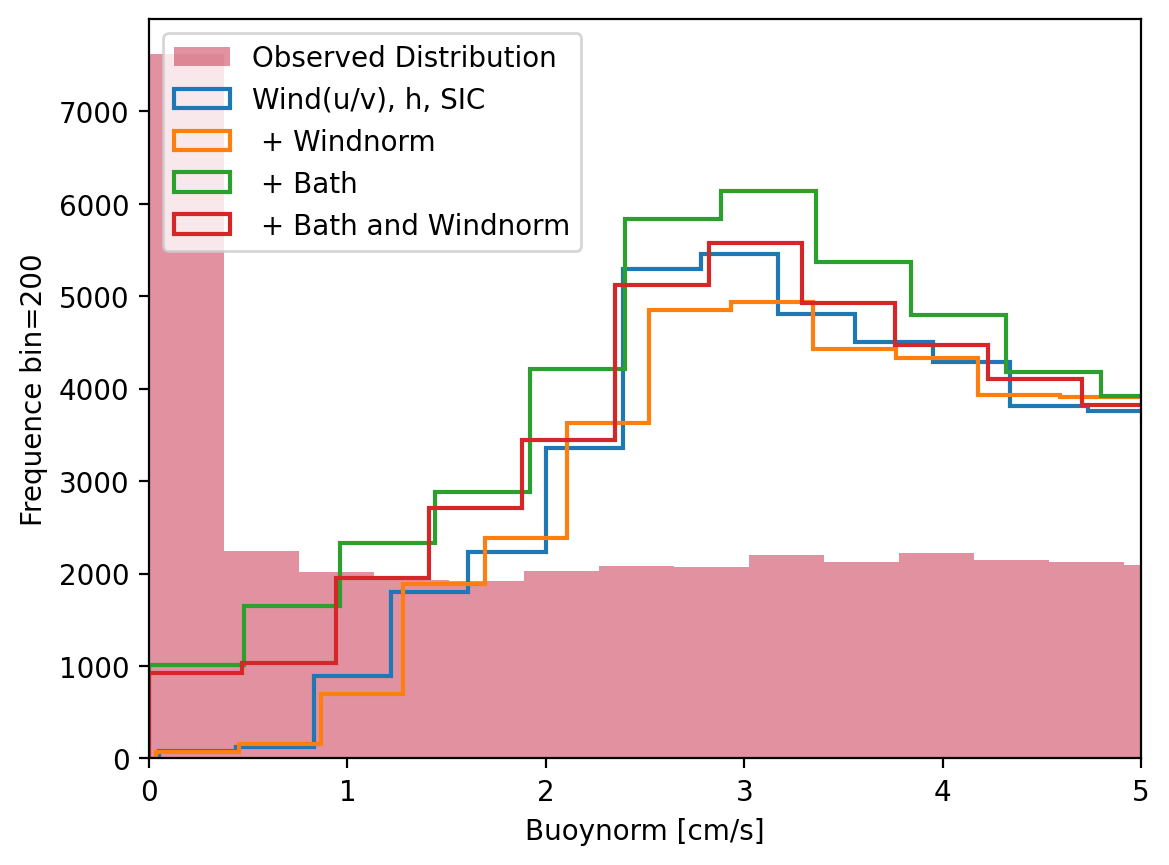

In [ ]:
import matplotlib.pyplot as plt
print(testdata.columns)



fig, ax =plt.subplots(dpi=200)
n_bins=200
lw=1.5
ax.hist(testdata['buoynorm'], n_bins, color= "#C52C4684", label='Observed Distribution')
ax.hist(testdata['usual'], n_bins, histtype='step', linewidth=lw, label='Wind(u/v), h, SIC')
ax.hist(testdata['usual+windnorm'], n_bins, histtype='step',linewidth=lw, #linestyle='--', 
        label=' + Windnorm')
ax.hist(testdata['bathnowind'], n_bins, histtype='step',linewidth=lw, #linestyle='dotted', 
        label=' + Bath')
ax.hist(testdata['bath+wind'], n_bins, histtype='step', linewidth=lw, #linestyle='-.', 
        label=' + Bath and Windnorm')



ax.legend()
#plt.xlim([-np.pi,np.pi])
ax.set_xlim([-0,5])
ax.set_ylabel(f'Frequence bin={n_bins}')
ax.set_xlabel('Buoynorm [cm/s]')
ax.legend()
plt.show()


